In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('marquette.csv', skiprows=5)
data = data.dropna(subset=['Rk'])

In [ ]:
data = data.rename(columns={
    'Rk': 'GameID', 'Date': 'Date', 'Opp': 'Opp', 'Rslt': 'W/L',
    'Tm': 'Points Scored', 'Opp.1': 'Opp Points',
    'FG': 'MU_FGM', 'FGA': 'MU_FGA', 'FG%': 'MU_FG_PCT',
    '3P': 'MU_3PM', '3PA': 'MU_3PA', '3P%': 'MU_3PCT',
    'FT': 'MU_FTM', 'FTA': 'MU_FTA', 'FT%': 'MU_FT_PCT',
    'ORB': 'MU_OFF_RB', 'TRB': 'MU_TRB', 'AST': 'MU_AST',
    'STL': 'MU_STL', 'BLK': 'MU_BLK', 'TOV': 'MU_TOV', 'PF': 'MU_PF',
    'FG.1': 'Opp_FGM', 'FGA.1': 'Opp_FGA', 'FG%.1': 'Opp_FG_PCT',
    '3P.1': 'Opp_3PM', '3PA.1': 'Opp_3PA', '3P%.1': 'Opp_3PCT',
    'FT.1': 'Opp_FTM', 'FTA.1': 'Opp_FTA', 'FT%.1': 'Opp_FT_PCT',
    'ORB.1': 'Opp_OFF_RB', 'TRB.1': 'Opp_TRB', 'AST.1': 'Opp_AST',
    'STL.1': 'Opp_STL', 'BLK.1': 'Opp_BLK', 'TOV.1': 'Opp_TOV', 'PF.1': 'Opp_PF',
})

In [ ]:
cols = ['GameID', 'Date', 'Opp', 'W/L', 'Points Scored', 'Opp Points',
        'MU_FGM', 'MU_FGA', 'MU_FG_PCT', 'MU_3PM', 'MU_3PA', 'MU_3PCT',
        'MU_FTM', 'MU_FTA', 'MU_FT_PCT', 'MU_OFF_RB', 'MU_TRB', 'MU_AST',
        'MU_STL', 'MU_BLK', 'MU_TOV', 'MU_PF',
        'Opp_FGM', 'Opp_FGA', 'Opp_FG_PCT', 'Opp_3PM', 'Opp_3PA', 'Opp_3PCT',
        'Opp_FTM', 'Opp_FTA', 'Opp_FT_PCT', 'Opp_OFF_RB', 'Opp_TRB', 'Opp_AST',
        'Opp_STL', 'Opp_BLK', 'Opp_TOV', 'Opp_PF']
data = data[cols]

numerics = data.columns.drop({'Date', 'Opp', 'W/L'})
data[numerics] = data[numerics].apply(pd.to_numeric)

data['W/L'] = data['W/L'].map({'L': 1, 'W': 0})

In [ ]:
#used random forest classifier to figure out the best variables for the dataset
X = data.drop(['W/L','Opp','Date'], axis=1)  # Features
y = data['W/L']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#random forest classifier to help filter out important variables.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

In [ ]:
importances = rf_model.feature_importances_

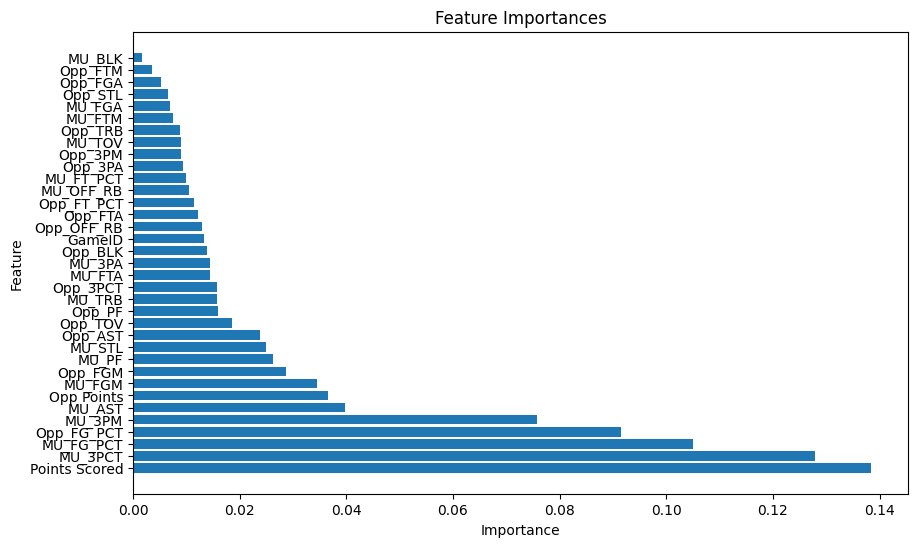

In [105]:
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': importances})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.show()

In [ ]:
# Select top 10 features
top_15_features = feature_importances.head(15)['feature'].tolist()

# Create a new DataFrame with only selected features
newDf = X[top_15_features]
newDf.loc[:, 'W/L'] = data[['W/L']]
newDf.head(8)

In [ ]:
#ended up dropping the new dataset with all the best variables because it overfitted the model.
X = data.drop(['W/L','Opp','Date'], axis=1)  
y = data['W/L']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [103]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Accuracy: 0.875
Confusion Matrix:
 [[6 1]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.50      1.00      0.67         1

    accuracy                           0.88         8
   macro avg       0.75      0.93      0.79         8
weighted avg       0.94      0.88      0.89         8



In [104]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 1 to 37
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   GameID         37 non-null     int64  
 1   Date           37 non-null     object 
 2   Opp            37 non-null     object 
 3   W/L            37 non-null     int64  
 4   Points Scored  37 non-null     int64  
 5   Opp Points     37 non-null     int64  
 6   MU_FGM         37 non-null     int64  
 7   MU_FGA         37 non-null     int64  
 8   MU_FG_PCT      37 non-null     float64
 9   MU_3PM         37 non-null     int64  
 10  MU_3PA         37 non-null     int64  
 11  MU_3PCT        37 non-null     float64
 12  MU_FTM         37 non-null     int64  
 13  MU_FTA         37 non-null     int64  
 14  MU_FT_PCT      37 non-null     float64
 15  MU_OFF_RB      37 non-null     int64  
 16  MU_TRB         37 non-null     int64  
 17  MU_AST         37 non-null     int64  
 18  MU_STL      